# Notebook 06 — Modèle LightGBM (affichage des résultats)

**Ce que le script a fait :**
1. Construire les mêmes **fenêtres** qu'aux notebooks 04 et 05
2. Pour **chaque fenêtre**, entraîner une petite grille LightGBM avec **arrêt anticipé**
   sur la validation de cette fenêtre
3. Mettre bout à bout les prédictions et calculer le **même R²_oos à la GKX**
4. Agréger l'importance des variables (gain/split) sur toutes les fenêtres + calculer les
   valeurs **SHAP** du modèle final (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal

## 0. Import et chargement des résultats

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('06_lightgbm')
print(rap.resume())

resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_LIGHTGBM)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE)

Rapport '06_lightgbm' produit le 2026-08-26T07:44:15


## 1. Données et fenêtres d'entraînement

In [2]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
print(f"Predicteurs : {rap.valeur('n_predicteurs')}")
rap.table('resume_fenetres')

Panel complet : (2615807, 49)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 49) (198002 a 202112)
Mode : rolling | 12 fenetres generees
Predicteurs : 30


,fenetre,train_debut,train_fin,n_mois_train,n_annees_train,validation_debut,validation_fin,n_annees_validation,test_debut,test_fin,annee_test
0,0,198002,199712,215,18,199801,200912,12,201001,201012,2010
1,1,198201,199912,216,18,200001,201012,11,201101,201112,2011
2,2,198401,200112,216,18,200201,201112,10,201201,201212,2012
3,3,198601,200312,216,18,200401,201212,9,201301,201312,2013
4,4,198801,200512,216,18,200601,201312,8,201401,201412,2014
5,5,199001,200712,216,18,200801,201412,7,201501,201512,2015
6,6,199201,200912,216,18,201001,201512,6,201601,201612,2016
7,7,199401,201112,216,18,201201,201612,5,201701,201712,2017
8,8,199601,201312,216,18,201401,201712,4,201801,201812,2018
9,9,199701,201412,216,18,201501,201812,4,201901,201912,2019


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les notebooks 04 et 05, indispensable pour comparer l'ensemble des modèles
équitablement au notebook 08 : `R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`.

## 3. Entraînement avec arrêt anticipé, fenêtre par fenêtre

Plutôt qu'une grande grille comme au notebook 05, on profite d'une fonctionnalité propre à
LightGBM : un budget large d'arbres, mais la performance sur la `validation` de la fenêtre en
cours est **surveillée à chaque arbre ajouté**, et l'entraînement s'arrête dès que ça
n'améliore plus depuis `STOPPING_ROUNDS_LIGHTGBM` arbres d'affilée. Ça évite le
sur-apprentissage et limite le nombre d'hyperparamètres à tester manuellement.

⚠️ Comme pour les autres modèles : c'est bien la `validation` de chaque fenêtre qui sert à
arrêter l'entraînement et à choisir les hyperparamètres, jamais son `test`.

In [3]:
print("Parametres SPECIFIQUES utilises (config.py) :")
for cle, valeur in rap.valeur('params_specifiques').items():
    print(f"  {cle} = {valeur}")
print()
print(f"Grille : {rap.valeur('n_combinaisons_grille')} combinaisons x "
      f"{rap.valeur('n_fenetres')} fenetres")
print(f"Duree totale (recherche d'hyperparametres incluse) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print()
resultats_par_fenetre['ecart_train_validation'] = (
    resultats_par_fenetre['r2_oos_train'] - resultats_par_fenetre['r2_oos_validation'])
resultats_par_fenetre.round(4)
resultats_par_fenetre

Parametres SPECIFIQUES utilises (config.py) :
  grille_num_leaves = [3, 7, 15]
  grille_learning_rate = [0.01]
  grille_min_child_samples = [2000]
  grille_n_estimators = [2000]
  stopping_rounds = 200

Grille : 3 combinaisons x 12 fenetres
Duree totale (recherche d'hyperparametres incluse) : 1118.0 s



,fenetre,annee_test,n_train,num_leaves,learning_rate,min_child_samples,n_estimators,nb_arbres_utilises,r2_oos_train,r2_oos_validation,r2_oos_test,ecart_train_validation
0,0,2010,1106697,15,0.01,2000,2000,1985,0.028473,0.004644,0.004299,0.023830
1,1,2011,1227639,7,0.01,2000,2000,1893,0.018559,0.004517,-0.006149,0.014042
2,2,2012,1300561,7,0.01,2000,2000,1138,0.016838,0.003798,0.007841,0.013040
3,3,2013,1314690,15,0.01,2000,2000,54,0.004420,0.001848,0.024053,0.002572
4,4,2014,1315628,7,0.01,2000,2000,519,0.011305,0.002818,-0.002326,0.008487
5,5,2015,1313001,15,0.01,2000,2000,490,0.018850,0.004114,-0.007103,0.014736
6,6,2016,1303842,3,0.01,2000,2000,150,0.003147,0.005945,0.008814,-0.002799
7,7,2017,1278025,7,0.01,2000,2000,135,0.004486,0.007267,0.007342,-0.002781
8,8,2018,1228236,15,0.01,2000,2000,62,0.005551,0.002789,-0.015129,0.002762
9,9,2019,1198983,15,0.01,2000,2000,41,0.004505,-0.001005,0.010345,0.005511


## 3bis. La grille complète : tous les modèles testés au dernier lancement

Comme pour l'Elastic Net, la section précédente ne montre que la combinaison **gagnante** de
chaque fenêtre, alors que le script en a entraîné bien davantage. La surface de performance
complète en dit plus que son seul maximum : un optimum plat indique un choix robuste, un
optimum pointu peut n'être qu'un artefact du bruit de cette période de validation.

ℹ️ Ces tableaux ne concernent que le **dernier lancement** du script. La comparaison entre
plusieurs lancements est le rôle du notebook 09.

In [4]:
grille = rap.table('grille_complete')

print(f"{rap.valeur('n_combinaisons_grille')} combinaisons x {rap.valeur('n_fenetres')} fenetres "
      f"= {rap.valeur('n_modeles_entraines_grille')} modeles entraines au total.")
print()

def _etiquettes(valeurs):
    # 1e-05 plutot que 9.999999999999e-06 : les flottants d'une grille se lisent mieux en %g
    return [f"{v:g}" if isinstance(v, float) else str(v) for v in valeurs]


def tracer_heatmap(pivot, titre, etiquette_couleur, cmap, format_valeur="{:.4f}"):
    # Heatmap annotee a partir d'un tableau croise (2 hyperparametres en lignes/colonnes)
    valeurs = pivot.values.astype(float)
    fig, ax = plt.subplots(figsize=(1.7 * len(pivot.columns) + 3.5,
                                    0.75 * len(pivot.index) + 2.5))
    image = ax.imshow(valeurs, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(_etiquettes(pivot.columns))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(_etiquettes(pivot.index))
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)
    ax.set_title(titre)

    milieu = (np.nanmax(valeurs) + np.nanmin(valeurs)) / 2
    for i in range(valeurs.shape[0]):
        for j in range(valeurs.shape[1]):
            v = valeurs[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, format_valeur.format(v), ha='center', va='center',
                    fontsize=9, color='white' if v < milieu else 'black')

    fig.colorbar(image, ax=ax, label=etiquette_couleur)
    plt.tight_layout()
    plt.show()

3 combinaisons x 12 fenetres = 36 modeles entraines au total.



### R²_oos de validation, moyenné sur les fenêtres

⚠️ Chaque case est la moyenne sur **toutes les fenêtres** et sur **toutes les valeurs de
`learning_rate` et `min_child_samples`** — ces deux hyperparamètres ne sont pas sur les axes.
La heatmap donne donc la tendance générale des deux paramètres qui t'intéressent ; le tableau
détaillé plus bas montre chaque combinaison individuellement.

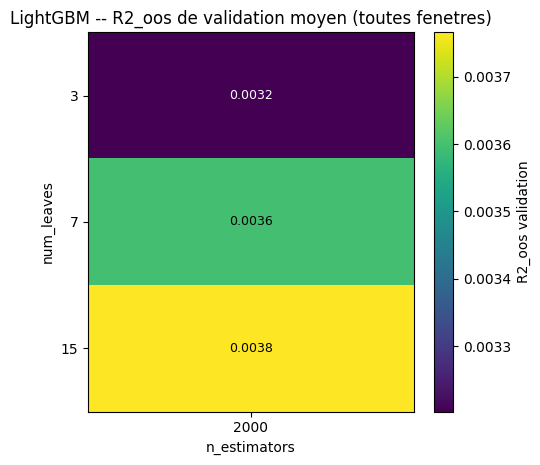

In [5]:
pivot_validation = grille.pivot_table(index='num_leaves', columns='n_estimators',
                                      values='r2_oos_validation', aggfunc='mean')
tracer_heatmap(pivot_validation,
               "LightGBM -- R2_oos de validation moyen (toutes fenetres)",
               "R2_oos validation", cmap='viridis')

In [6]:
cles = ['num_leaves', 'n_estimators', 'learning_rate', 'min_child_samples']

resume_grille = (grille.groupby(cles)
                 .agg(r2_train=('r2_oos_train', 'mean'),
                      r2_validation=('r2_oos_validation', 'mean'),
                      ecart=('ecart_train_validation', 'mean'),
                      arbres_moyens=('nb_arbres_utilises', 'mean'),
                      fois_selectionnee=('selectionnee', 'sum')))

# Deux rangs plutot que deux tableaux : rang_val = 1 -> meilleure validation,
# rang_ecart = 1 -> ecart train-validation le plus faible (sur-apprend le moins).
resume_grille['rang_val'] = resume_grille['r2_validation'].rank(ascending=False).astype(int)
resume_grille['rang_ecart'] = resume_grille['ecart'].rank().astype(int)
resume_grille = resume_grille.sort_values('r2_validation', ascending=False)

print("Toutes les combinaisons, classees par R2_oos de validation moyen.")
print("rang_ecart en regard : une combinaison bien classee sur les DEUX rangs est le")
print("choix le plus sur ; un ecart faible sur un modele qui ne predit rien n'a aucun interet.")
resume_grille.round(4)

Toutes les combinaisons, classees par R2_oos de validation moyen.
rang_ecart en regard : une combinaison bien classee sur les DEUX rangs est le
choix le plus sur ; un ecart faible sur un modele qui ne predit rien n'a aucun interet.


,,,,r2_train,r2_validation,ecart,arbres_moyens,fois_selectionnee,rang_val,rang_ecart
num_leaves,n_estimators,learning_rate,min_child_samples,,,,,,,
15,2000,0.01,2000,0.0116,0.0038,0.0078,394.5833,7,1,3
7,2000,0.01,2000,0.0087,0.0036,0.0051,565.0833,4,2,2
3,2000,0.01,2000,0.0049,0.0032,0.0017,599.5000,1,3,1


### L'écart train − validation : quelle combinaison sur-apprend le moins ?

Le point est encore plus critique ici que sur l'Elastic Net : un modèle de gradient boosting
peut atteindre un R² d'entraînement très élevé en mémorisant du bruit, ce qui ne se voit pas
du tout dans son R² de validation pris isolément.

- **Écart large et positif** → sur-apprentissage. Sur LightGBM, les coupables habituels sont
  un `num_leaves` trop grand, un `min_child_samples` trop petit, ou un budget d'arbres que
  l'arrêt anticipé ne parvient pas à contenir.
- **Écart proche de zéro** → le modèle généralise. Sur des rendements mensuels, c'est
  généralement du côté des arbres **peu profonds** qu'on le trouve.
- **Écart négatif** → le modèle n'apprend presque rien et prédit quasiment zéro partout.

⚠️ Diagnostic, pas critère de sélection : le script choisit toujours sur le meilleur R²_oos
de validation. Pour sélectionner sur l'écart, il faut modifier la ligne
`meilleur_index = ...` dans `scripts/etape06_modele_lightgbm.py`.

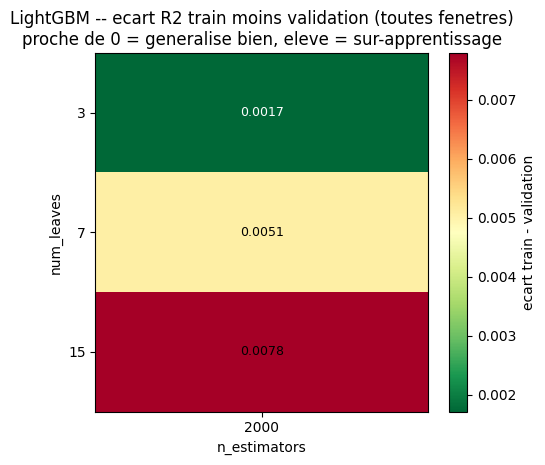

In [7]:
pivot_ecart = grille.pivot_table(index='num_leaves', columns='n_estimators',
                                 values='ecart_train_validation', aggfunc='mean')
tracer_heatmap(pivot_ecart,
               "LightGBM -- ecart R2 train moins validation (toutes fenetres)\n"
               "proche de 0 = generalise bien, eleve = sur-apprentissage",
               "ecart train - validation", cmap='RdYlGn_r')

## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

Même logique qu'aux notebooks 04 et 05 : toutes les prédictions bout à bout **d'abord**,
puis un seul R²_oos sur chaque série complète — plutôt qu'une moyenne (biaisée) des R² par
fenêtre.

In [8]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0106
R2_oos validation (pooled, toutes fenetres) : 0.0040
R2_oos test       (pooled, toutes fenetres) : 0.0048



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,LightGBM,rolling,12,0.010631,0.004007,0.004796,42d15a62b2845eff


## 5. Évolution du R²_oos et du nombre d'arbres au fil des fenêtres

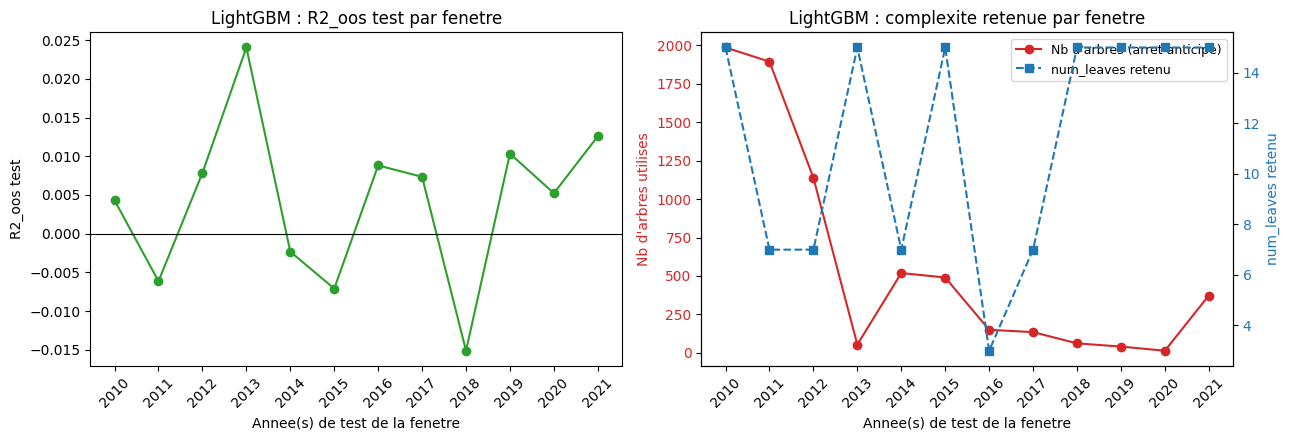

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'],
             marker='o', color='tab:green')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("LightGBM : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

# Deux echelles differentes (des centaines d'arbres contre des dizaines de feuilles) :
# le nb de feuilles va sur un second axe a droite, sinon sa courbe s'ecrase sur zero.
axes[1].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['nb_arbres_utilises'],
             marker='o', color='tab:red', label="Nb d'arbres (arret anticipe)")
axes[1].set_xlabel("Annee(s) de test de la fenetre")
axes[1].set_ylabel("Nb d'arbres utilises", color='tab:red')
axes[1].tick_params(axis='y', labelcolor='tab:red')
axes[1].tick_params(axis='x', rotation=45)

ax_feuilles = axes[1].twinx()
ax_feuilles.plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['num_leaves'],
                 marker='s', linestyle='--', color='tab:blue', label="num_leaves retenu")
ax_feuilles.set_ylabel("num_leaves retenu", color='tab:blue')
ax_feuilles.tick_params(axis='y', labelcolor='tab:blue')

axes[1].set_title("LightGBM : complexite retenue par fenetre")

# Une seule legende pour les deux axes superposes
lignes_1, etiquettes_1 = axes[1].get_legend_handles_labels()
lignes_2, etiquettes_2 = ax_feuilles.get_legend_handles_labels()
axes[1].legend(lignes_1 + lignes_2, etiquettes_1 + etiquettes_2, fontsize=9, loc='best')

plt.tight_layout()
plt.show()

## 6. Coup d'œil rapide à l'importance des variables (modèle de la dernière fenêtre)

Contrairement à l'Elastic Net (qui ramène des coefficients à 0), LightGBM donne un score
d'importance basé sur la contribution de chaque variable à la réduction de l'erreur
(`gain`). On regarde ici le modèle de la **dernière fenêtre** — un simple instantané, qui
peut varier d'une fenêtre à l'autre.

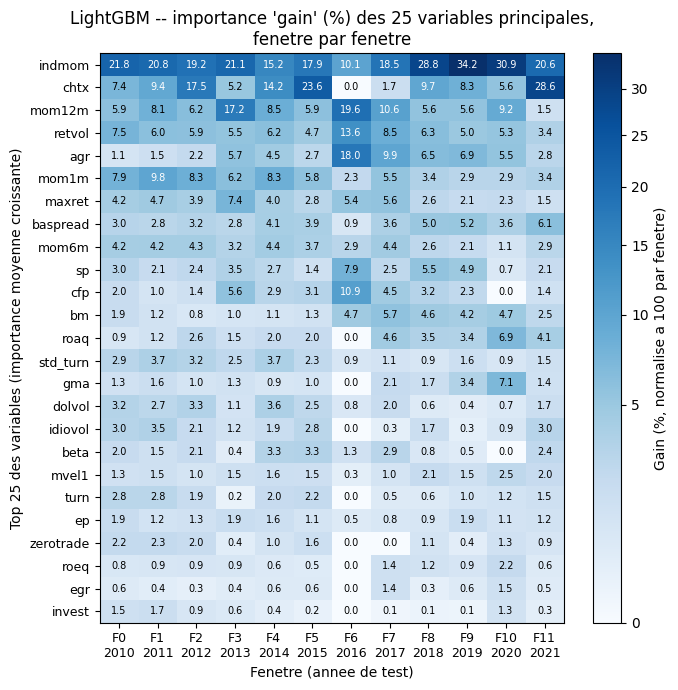

In [10]:
from matplotlib.colors import PowerNorm


# Heatmap : top 25 des variables (lignes) x fenetres (colonnes).
# Le gain est deja normalise a 100 par fenetre par le script, donc les colonnes sont
# comparables entre elles malgre des nombres d'arbres differents.
gain_par_fenetre = rap.table('gain_par_fenetre')          # lignes = fenetres, colonnes = variables
resultats_par_fenetre = resultats_par_fenetre.sort_values('fenetre')

N_TOP = 25
TAILLE_FIGURE = (7, 7)          # <-- largeur, hauteur, en pouces

# Classement par gain MOYEN sur toutes les fenetres, croissant : la plus importante
# se retrouve en haut avec origin='lower' (la moins importante pres de l'origine).
gain_moyen = gain_par_fenetre.mean()
top = gain_moyen.nlargest(N_TOP).sort_values(ascending=True).index

matrice = gain_par_fenetre.loc[resultats_par_fenetre['fenetre'], top].T   # variables x fenetres
valeurs = matrice.values.astype(float)

# Etiquettes de colonnes : "F1\n2005" -- le numero de fenetre ET son annee de test
etiquettes_x = [f"F{int(f)}\n{a}" for f, a in
                zip(resultats_par_fenetre['fenetre'], resultats_par_fenetre['annee_test'])]

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)
image = ax.imshow(valeurs, cmap='Blues', aspect='auto', origin='lower',
                  norm=PowerNorm(gamma=0.5, vmin=0, vmax=valeurs.max()))

ax.set_xticks(range(valeurs.shape[1]))
ax.set_xticklabels(etiquettes_x, fontsize=9)
ax.set_yticks(range(valeurs.shape[0]))
ax.set_yticklabels(matrice.index, fontsize=9)
ax.set_xlabel("Fenetre (annee de test)")
ax.set_ylabel(f"Top {N_TOP} des variables (importance moyenne croissante)")
ax.set_title(f"LightGBM -- importance 'gain' (%) des {N_TOP} variables principales,\n"
             "fenetre par fenetre")

milieu = float(image.norm.inverse(0.5))
for i in range(valeurs.shape[0]):
    for j in range(valeurs.shape[1]):
        v = valeurs[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.1f}", ha='center', va='center', fontsize=7,
                color='white' if v > milieu else 'black')

fig.colorbar(image, ax=ax, label="Gain (%, normalise a 100 par fenetre)")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "importance_lightgbm_par_fenetre.png",
            dpi=300, bbox_inches='tight')
plt.show()

## 6bis. Importance agrégée sur toutes les fenêtres (+ SHAP)

L'importance du modèle de la **dernière fenêtre** seule peut être trompeuse : LightGBM peut
redistribuer l'importance différemment d'une fenêtre à l'autre (arbres différents, arrêt
anticipé différent), même si le pouvoir prédictif global reste stable. On regarde donc deux
mesures natives, moyennées **avec leur écart-type** (pour juger la stabilité) sur toutes les
fenêtres :

- **`gain`** : réduction totale de l'erreur apportée par les splits utilisant cette variable
  — la mesure la plus informative économiquement, normalisée à 100 par fenêtre pour rester
  comparable malgré des nombres d'arbres différents.
- **`split`** : nombre de fois que la variable est utilisée pour couper un nœud — mesure la
  fréquence d'usage plutôt que l'impact, utile pour repérer des variables souvent utilisées
  mais pour des gains marginaux.

In [11]:
importance_agregee = pd.read_parquet(config.FICHIER_IMPORTANCE_LIGHTGBM)

print(f"Importance agregee sur {rap.valeur('n_fenetres')} fenetres.")
print(f"{rap.valeur('imp_n_jamais_utilisees')} / {rap.valeur('imp_n_predicteurs')} predicteurs "
      "ne sont utilises dans AUCUN arbre d'aucune fenetre.")
print()
print("Top 20 des predicteurs par gain moyen (avec leur variabilite d'une fenetre a l'autre) :")
importance_agregee.head(20).round(3)

Importance agregee sur 12 fenetres.
0 / 30 predicteurs ne sont utilises dans AUCUN arbre d'aucune fenetre.

Top 20 des predicteurs par gain moyen (avec leur variabilite d'une fenetre a l'autre) :


,gain_moyen_pct,gain_ecart_type_pct,split_moyen,split_ecart_type,jamais_utilisee_pct_fenetres
indmom,21.583,6.741,871.667,1207.120,0.000
chtx,10.923,8.604,346.917,394.386,8.333
mom12m,8.653,5.121,257.917,348.345,0.000
retvol,6.498,2.585,274.500,372.666,0.000
agr,5.598,4.676,132.750,113.317,0.000
mom1m,5.557,2.571,426.500,617.633,0.000
maxret,3.873,1.728,189.083,288.643,0.000
baspread,3.680,1.367,220.917,318.101,0.000
mom6m,3.317,1.064,253.417,367.826,0.000
sp,3.221,1.988,135.167,209.886,0.000


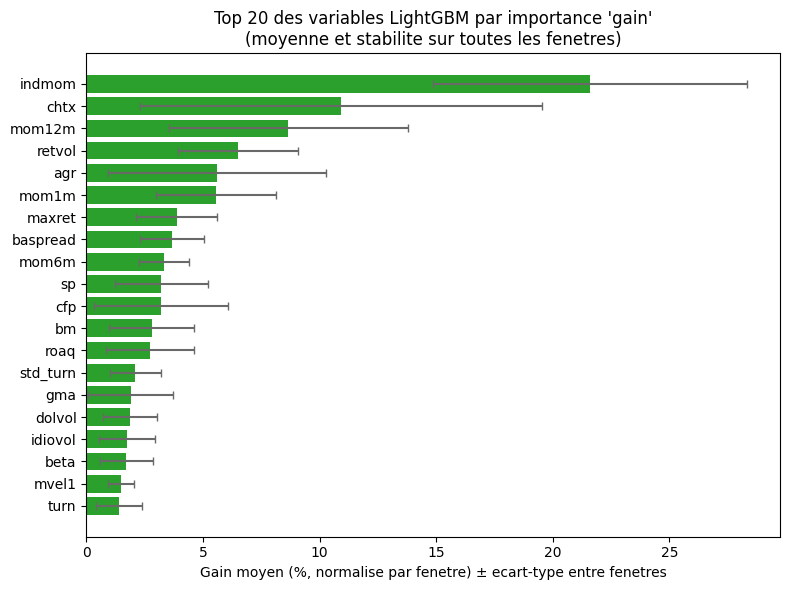

In [12]:
top20_imp = importance_agregee.head(20).sort_values('gain_moyen_pct')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_imp.index, top20_imp['gain_moyen_pct'],
        xerr=top20_imp['gain_ecart_type_pct'], color='tab:green', ecolor='dimgray', capsize=3)
ax.set_xlabel("Gain moyen (%, normalise par fenetre) ± ecart-type entre fenetres")
ax.set_title("Top 20 des variables LightGBM par importance 'gain'\n"
             "(moyenne et stabilite sur toutes les fenetres)")
plt.tight_layout()
plt.show()

### SHAP — contributions signées du modèle de la dernière fenêtre

Contrairement à `gain`/`split` (agrégés, sans direction), SHAP (Lundberg & Lee, 2017) donne
une contribution **signée** par variable et par observation — utile pour voir non seulement
*quelles* variables comptent, mais aussi *dans quel sens*.

⚠️ Les valeurs SHAP sont **calculées par le script** (l'explainer est coûteux) et stockées
dans le rapport : la cellule ci-dessous ne fait que tracer le graphique à partir de ces
valeurs déjà calculées.

c:\Users\aless\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


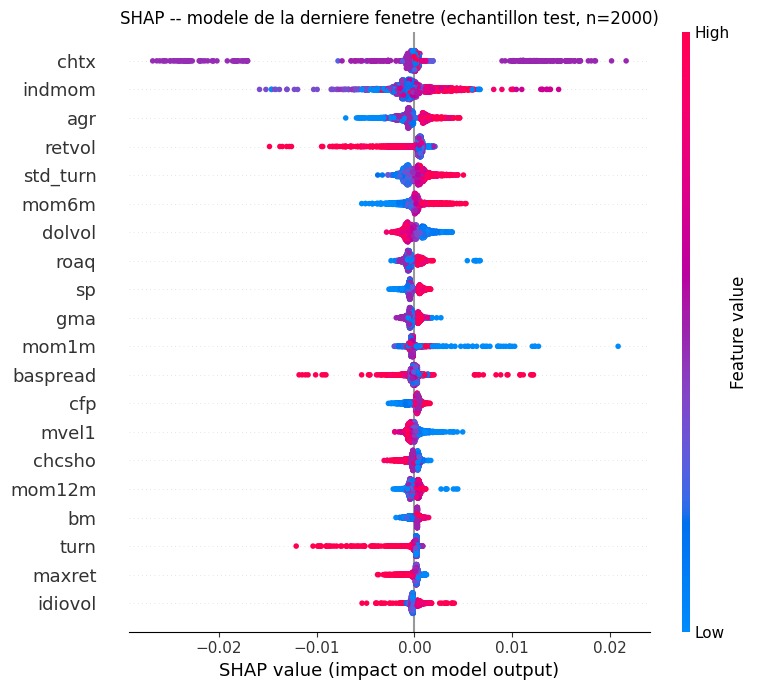

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire - Copy (2)\outputs\shap_lightgbm_derniere_fenetre.png


In [13]:
if not rap.valeur('shap_calcule'):
    print("Les valeurs SHAP n'ont pas ete calculees (package 'shap' absent, ou script lance")
    print("avec --sans-shap). Pour les obtenir : pip install shap, puis")
    print("    python scripts/etape06_modele_lightgbm.py")
else:
    import shap

    valeurs_shap = rap.table('shap_valeurs')
    X_echantillon = rap.table('shap_echantillon_X')
    n = rap.valeur('shap_taille_echantillon')

    shap.summary_plot(valeurs_shap.values, X_echantillon, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(8, 7)
    plt.title(f"SHAP -- modele de la derniere fenetre (echantillon test, n={n})")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png", dpi=150)
    plt.show()
    print("Graphique sauvegarde :", config.OUTPUTS_DIR / "shap_lightgbm_derniere_fenetre.png")

## 9. Résumé et prochaines étapes

- Hyperparamètres (`num_leaves`, `learning_rate`, `min_child_samples`) choisis par petite
  grille, avec arrêt anticipé sur la `validation` de **chaque fenêtre** pour fixer
  automatiquement le nombre d'arbres.
- Même métrique et même logique de fenêtres que les notebooks 04 et 05.
- **Importance (section 6bis)** : gain et split moyennés (avec écart-type) sur **toutes** les
  fenêtres, plus une analyse SHAP signée du modèle final.

**Étape suivante :** ouvre `07_modele_random_forest.ipynb` (le 4e et dernier modèle), puis
`08_evaluation_portefeuilles.ipynb` (portefeuilles long-short par décile, et portefeuille
combiné en partie C) et `09_comparaison_experiences.ipynb` (comparaison de tous les
lancements passés).